# Analysing State-wise Surface Water Quality Analysis in India (2003–2014)

This project analyzes surface water quality measurements collected from monitoring stations across different Indian states. The objective is to assess water quality conditions using key environmental indicators such as Dissolved Oxygen, pH, Conductivity, BOD, Nitrate, and Coliform counts.

**Dataset Dimensions**

Rows - 1991, Columns- 12

**Column Description:**

| Column                           | Description                          |
| -------------------------------- | ------------------------------------ |
| STATION CODE                     | Unique monitoring station identifier |
| LOCATIONS                        | Water sampling location              |
| STATE                            | State/UT where sample was collected  |
| Temp                             | Water temperature (°C)               |
| D.O. (mg/l)                      | Dissolved Oxygen                     |
| PH                               | Acidity/Alkalinity level             |
| CONDUCTIVITY (µmhos/cm)          | Electrical conductivity              |
| B.O.D. (mg/l)                    | Biological Oxygen Demand             |
| NITRATENAN N+ NITRITENANN (mg/l) | Nitrate and Nitrite concentration    |
| FECAL COLIFORM (MPN/100ml)       | Fecal contamination indicator        |
| TOTAL COLIFORM (MPN/100ml)Mean   | Total coliform bacteria count        |
| year                             | Year of observation                  |


**Observations:**


The dataset contains water quality readings from multiple states such as:

1.Goa

2.Daman & Diu

3.Kerala

4.Tamil Nadu

5.Maharashtra

Years range from: 2003-2014


**Dataset Scope**

The dataset can be used to:

Compare water quality across states.

Identify polluted water bodies.

Analyze trends over time.

Study bacterial contamination levels.

Evaluate environmental health using standard water quality indicators.

**Key Insights From Initial analysis:**
Coverage
1,991 observations collected over 12 years.

Water quality monitored across numerous Indian states and UTs.

**Important Indicators**

1.Dissolved Oxygen (DO)

2.Biological Oxygen Demand (BOD)

3.pH

4.Conductivity

5.Coliform Counts

**Data Quality Issues**

1.Significant missing values.

2.Numeric columns stored as text.

3.One duplicate record.

4.Some station and location information missing.

**Recommended EDA Visualizations**

1.State-wise Sample Count (Count Plot)

2.Average DO by State (Bar Chart)

3.Year-wise Water Quality Trend (Line Plot)

4.BOD Distribution (Histogram)

5.Correlation Heatmap

6.Top 10 Most Polluted States by BOD

7.Fecal Coliform Distribution (Box Plot)

8.pH Distribution Across States (Violin Plot)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Data Loading and Initial Overview

In [ ]:
# Import the Pandas library for data analysis
url = "https://github.com/mohanarajrd/State-wise-surface-water-quality-/raw/refs/heads/main/State%20wise%20surface%20water%20quality.csv"

df = pd.read_csv(url, encoding='latin1')
df.head(10)

,STATION CODE,LOCATIONS,STATE,Temp,D.O. (mg/l),PH,CONDUCTIVITY (µmhos/cm),B.O.D. (mg/l),NITRATENAN N+ NITRITENANN (mg/l),FECAL COLIFORM (MPN/100ml),TOTAL COLIFORM (MPN/100ml)Mean,year
0,1393,"DAMANGANGA AT D/S OF MADHUBAN, DAMAN",DAMAN & DIU,30.6,6.7,7.5,203,NAN,0.1,11,27,2014
1,1399,ZUARI AT D/S OF PT. WHERE KUMBARJRIA CANAL JOI...,GOA,29.8,5.7,7.2,189,2,0.2,4953,8391,2014
2,1475,ZUARI AT PANCHAWADI,GOA,29.5,6.3,6.9,179,1.7,0.1,3243,5330,2014
3,3181,RIVER ZUARI AT BORIM BRIDGE,GOA,29.7,5.8,6.9,64,3.8,0.5,5382,8443,2014
4,3182,RIVER ZUARI AT MARCAIM JETTY,GOA,29.5,5.8,7.3,83,1.9,0.4,3428,5500,2014
5,1400,"MANDOVI AT NEGHBOURHOOD OF PANAJI, GOA",GOA,30,5.5,7.4,81,1.5,0.1,2853,4049,2014
6,1476,"MANDOVI AT TONCA, MARCELA, GOA",GOA,29.2,6.1,6.7,308,1.4,0.3,3355,5672,2014
7,3185,RIVER MANDOVI AT AMONA BRIDGE,GOA,29.6,6.4,6.7,414,1,0.2,6073,9423,2014
8,3186,RIVER MANDOVI AT IFFI JETTY,GOA,30,6.4,7.6,305,2.2,0.1,3478,4990,2014
9,3187,RIVER MANDOVI NEAR HOTEL MARRIOT,GOA,30.1,6.3,7.6,77,2.3,0.1,2606,4301,2014


In [ ]:
# Display the number of rows and columns in the dataset
print("Shape of Dataset:", df.shape)

# Display all column names
print("\nColumn Names:")
print(df.columns.tolist())

# Display data types of each column
print("\nData Types:")
print(df.dtypes)

# Get information about the dataset
print("\nDataset Information:")
df.info()

Shape of Dataset: (1991, 12)

Column Names:
['STATION CODE', 'LOCATIONS', 'STATE', 'Temp', 'D.O. (mg/l)', 'PH', 'CONDUCTIVITY (µmhos/cm)', 'B.O.D. (mg/l)', 'NITRATENAN N+ NITRITENANN (mg/l)', 'FECAL COLIFORM (MPN/100ml)', 'TOTAL COLIFORM (MPN/100ml)Mean', 'year']

Data Types:
STATION CODE                        object
LOCATIONS                           object
STATE                               object
Temp                                object
D.O. (mg/l)                         object
PH                                  object
CONDUCTIVITY (µmhos/cm)             object
B.O.D. (mg/l)                       object
NITRATENAN N+ NITRITENANN (mg/l)    object
FECAL COLIFORM (MPN/100ml)          object
TOTAL COLIFORM (MPN/100ml)Mean      object
year                                 int64
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1991 entries, 0 to 1990
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype 
--

# Statistical Summary

In [ ]:
# Generate statistical summary for numerical columns
df.describe()

,year
count,1991.000000
mean,2010.038172
std,3.057333
min,2003.000000
25%,2008.000000
50%,2011.000000
75%,2013.000000
max,2014.000000


# 2. Data Pre-processing

# Missing Values

In [ ]:
# Import NumPy for handling missing values
import numpy as np

# Replace string 'NAN' with actual null values
df.replace('NAN', np.nan, inplace=True)

# Check missing values in each column
df.isnull().sum()

,0
STATION CODE,122
LOCATIONS,184
STATE,761
Temp,88
D.O. (mg/l),31
PH,8
CONDUCTIVITY (µmhos/cm),25
B.O.D. (mg/l),40
NITRATENAN N+ NITRITENANN (mg/l),220
FECAL COLIFORM (MPN/100ml),303


# Duplicate Records

In [ ]:
# Check the number of duplicate rows
print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 1


In [ ]:
# Remove duplicate rows from the dataset
df.drop_duplicates(inplace=True)
print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 0


# Convert Data Types

In [ ]:
# List of columns that should be numeric
numeric_cols = [
    'Temp',
    'D.O. (mg/l)',
    'PH',
    'CONDUCTIVITY (µmhos/cm)',
    'B.O.D. (mg/l)',
    'NITRATENAN N+ NITRITENANN (mg/l)',
    'FECAL COLIFORM (MPN/100ml)',
    'TOTAL COLIFORM (MPN/100ml)Mean'
]

# Convert columns to numeric datatype
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Handle Missing Values

In [ ]:
# Fill missing values in numerical columns using median
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill missing values in categorical columns using mode
df['STATE'] = df['STATE'].fillna(df['STATE'].mode()[0])
df['LOCATIONS'] = df['LOCATIONS'].fillna(df['LOCATIONS'].mode()[0])

# Create Derived Column

In [ ]:
# Categorize water quality based on Dissolved Oxygen level
df['Water_Quality'] = df['D.O. (mg/l)'].apply(
    lambda x: 'Good' if x >= 5 else 'Poor'
)

# Display newly created column
df[['D.O. (mg/l)', 'Water_Quality']].head()

,D.O. (mg/l),Water_Quality
0,6.7,Good
1,5.7,Good
2,6.3,Good
3,5.8,Good
4,5.8,Good


# Filtering Data

In [ ]:
#Example 1: Data for Tamil Nadu
tamilnadu_df = df[df['STATE'] == 'TAMILNADU']

tamilnadu_df.head()

,STATION CODE,LOCATIONS,STATE,Temp,D.O. (mg/l),PH,CONDUCTIVITY (µmhos/cm),B.O.D. (mg/l),NITRATENAN N+ NITRITENANN (mg/l),FECAL COLIFORM (MPN/100ml),TOTAL COLIFORM (MPN/100ml)Mean,year,Water_Quality
159,1450,"PALAR AT VANIYAMBADI WATER SUPPLY HEAD WORK, T...",TAMILNADU,29.3,6.5,7.4,1063.0,2.0,0.6,177.0,374.0,2014,Good
160,1159,TAMBIRAPARANI AT BDG.NR. MADURA COATS LTD.PAPA...,TAMILNADU,22.8,6.8,6.6,63.0,2.9,0.1,11.0,36.0,2014,Good
161,1160,"TAMBIRAPARANI AT CHERANMADEVI,CAUSE WAY,TAMILNADU",TAMILNADU,24.5,6.6,6.4,101.0,2.5,0.2,13.0,41.0,2014,Good
162,1161,"TAMBIRAPARANI AT TIRUNELVELI,COLLECTORATE,TAMI...",TAMILNADU,25.5,6.6,6.5,136.0,2.5,0.2,13.0,45.0,2014,Good
163,1162,"TAMBIRAPARANI AT MURAPPANADU, TAMILNADU",TAMILNADU,29.0,6.7,6.9,226.0,2.2,0.2,12.0,38.0,2014,Good


In [ ]:
#Example 2: Good Water Quality Records
good_water = df[df['D.O. (mg/l)'] >= 5]

good_water.head()

,STATION CODE,LOCATIONS,STATE,Temp,D.O. (mg/l),PH,CONDUCTIVITY (µmhos/cm),B.O.D. (mg/l),NITRATENAN N+ NITRITENANN (mg/l),FECAL COLIFORM (MPN/100ml),TOTAL COLIFORM (MPN/100ml)Mean,year,Water_Quality
0,1393,"DAMANGANGA AT D/S OF MADHUBAN, DAMAN",DAMAN & DIU,30.6,6.7,7.5,203.0,1.8965,0.1,11.0,27.0,2014,Good
1,1399,ZUARI AT D/S OF PT. WHERE KUMBARJRIA CANAL JOI...,GOA,29.8,5.7,7.2,189.0,2.0000,0.2,4953.0,8391.0,2014,Good
2,1475,ZUARI AT PANCHAWADI,GOA,29.5,6.3,6.9,179.0,1.7000,0.1,3243.0,5330.0,2014,Good
3,3181,RIVER ZUARI AT BORIM BRIDGE,GOA,29.7,5.8,6.9,64.0,3.8000,0.5,5382.0,8443.0,2014,Good
4,3182,RIVER ZUARI AT MARCAIM JETTY,GOA,29.5,5.8,7.3,83.0,1.9000,0.4,3428.0,5500.0,2014,Good


In [ ]:
#Example 3: High Pollution Records
high_bod = df[df['B.O.D. (mg/l)'] > 5]

high_bod.head()

,STATION CODE,LOCATIONS,STATE,Temp,D.O. (mg/l),PH,CONDUCTIVITY (µmhos/cm),B.O.D. (mg/l),NITRATENAN N+ NITRITENANN (mg/l),FECAL COLIFORM (MPN/100ml),TOTAL COLIFORM (MPN/100ml)Mean,year,Water_Quality
31,2653,"BHATSA RIVER AT D/S OF LIBERTY OIL MILLS, SATN...",MAHARASHTRA,27.4,6.8,7.7,85.0,5.2,0.3,11.0,23.0,2014,Good
33,1092,"KALU AT ATALE VILLAGE, MAHARASHTRA",MAHARASHTRA,30.6,5.1,7.3,3937.0,10.3,1.8,31.0,83.0,2014,Good
35,1152,"KUNDALIKA AT ROHA CITY, MAHARASHTRA",MAHARASHTRA,25.0,6.4,7.6,541.0,5.7,0.6,23.0,45.0,2014,Good
36,2198,KUNDALIKA RIVER AT ARE KHURD ( SALINE ZONE ),MAHARASHTRA,25.0,5.5,7.4,6166.0,7.7,1.1,44.0,67.0,2014,Good
37,2671,KUNDALIKA RIVER NEAR SALAV BRIDGE (SALINA ZONE...,MAHARASHTRA,25.3,5.3,7.7,24062.0,9.9,1.2,156.0,304.0,2014,Good


In [ ]:
#Aggregation using GroupBy
#Average Water Quality Parameters by State

state_avg = df.groupby('STATE')[[
    'D.O. (mg/l)',
    'PH',
    'B.O.D. (mg/l)'
]].mean()

state_avg.head()

,D.O. (mg/l),PH,B.O.D. (mg/l)
STATE,,,
RIVER GHAGGAR AT D/S OF SURAJPUR,7.0,7.8,2.5
"ACHENKOIL AT CHENNITHULA, KERALA",6.4,7.0,0.8
"ACHENKOIL AT THUMPAMON, KERALA",6.8,7.0,0.6
"AMBIKA AT BILIMORA, GUJARAT",6.1,8.1,3.2
"AMLAKHADI AFTER CONFL. OF W. WATER FROM ANKLESH,GUJARAT",0.6,7.1,36.5


In [ ]:
#Year-wise Average Dissolved Oxygen

year_avg = df.groupby('year')['D.O. (mg/l)'].mean()

print(year_avg)

year
2003    7.187500
2004    7.650000
2005    6.505042
2006    6.409838
2007    6.360000
2008    6.169811
2009    6.310912
2010    6.351915
2011    6.227706
2012    6.632534
2013    6.328077
2014    6.262857
Name: D.O. (mg/l), dtype: float64


In [ ]:
#Number of Samples per State
sample_count = df.groupby('STATE').size().sort_values(ascending=False)

print(sample_count)

STATE
KERALA                                                    1035
MAHARASHTRA                                                142
MEGHALAYA                                                  125
GOA                                                        101
MANIPUR                                                     76
                                                          ... 
VAMANAPURAM, KERALA                                          1
Vansdhara GUNUPUR (INTERSTATE BOUNDRY)                       1
Vansdhara MUNIGUDA (D/S OF M/S VEDANTAALUMINA PROJECT)       1
ZUARI AT D/S OF PT. WHERE KUMBARJRIA CANAL JOINS, GOA        1
ZUARI AT PANCHAWADI                                          1
Length: 202, dtype: int64


# Outliers

Outliers capped successfully


<Axes: xlabel='B.O.D. (mg/l)'>

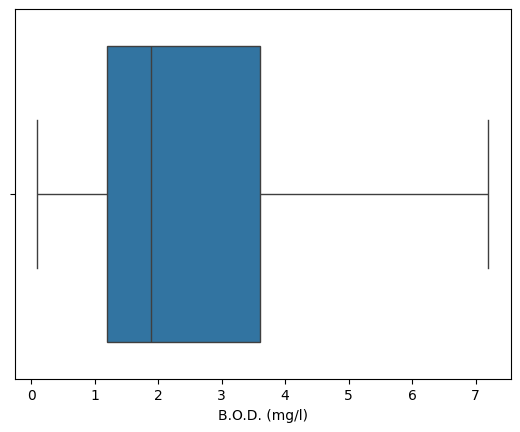

In [ ]:
# List of numerical columns for outlier treatment
numeric_cols = [
    'Temp',
    'D.O. (mg/l)',
    'PH',
    'CONDUCTIVITY (µmhos/cm)',
    'B.O.D. (mg/l)',
    'NITRATENAN N+ NITRITENANN (mg/l)',
    'FECAL COLIFORM (MPN/100ml)',
    'TOTAL COLIFORM (MPN/100ml)Mean'
]

# Loop through each numerical column
for col in numeric_cols:

    # Calculate the first quartile (25th percentile)
    Q1 = df[col].quantile(0.25)

    # Calculate the third quartile (75th percentile)
    Q3 = df[col].quantile(0.75)

    # Calculate Interquartile Range (IQR)
    IQR = Q3 - Q1

    # Define lower bound for outlier detection
    lower_bound = Q1 - 1.5 * IQR

    # Define upper bound for outlier detection
    upper_bound = Q3 + 1.5 * IQR

    # Cap values below lower bound and above upper bound
    # This preserves all records while reducing the impact of extreme values
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

# Display confirmation message
print("Outliers capped successfully")

sns.boxplot(x=df['B.O.D. (mg/l)'])

After applying IQR-based outlier treatment, no significant outliers were observed in the B.O.D. variable, indicating that extreme values were effectively controlled.

# **Statistical Summaries**

In [ ]:
# Mean, Median, Standard Deviation
df[numeric_cols].agg(
    ['mean', 'median', 'std', 'min', 'max']
)

,Temp,D.O. (mg/l),PH,CONDUCTIVITY (µmhos/cm),B.O.D. (mg/l),NITRATENAN N+ NITRITENANN (mg/l),FECAL COLIFORM (MPN/100ml),TOTAL COLIFORM (MPN/100ml)Mean
mean,26.370680,6.471546,7.324109,397.124927,2.733498,0.887279,457.951395,1168.125691
median,27.000000,6.700000,7.300000,183.000000,1.896500,0.516000,221.000000,468.000000
std,2.965905,1.076944,0.615325,441.520210,2.169813,0.861201,547.889369,1446.596844
min,20.050000,4.012500,5.700000,0.400000,0.100000,0.000000,0.000000,0.000000
max,33.250000,9.112500,8.900000,1303.375000,7.200000,2.580000,1511.625000,4068.625000


# **Kurtosis**

In [ ]:
# Kurtosis

df[numeric_cols].kurtosis()



,0
Temp,-0.193444
D.O. (mg/l),0.174725
PH,0.542148
CONDUCTIVITY (µmhos/cm),-0.125175
B.O.D. (mg/l),-0.090924
NITRATENAN N+ NITRITENANN (mg/l),-0.304843
FECAL COLIFORM (MPN/100ml),-0.337839
TOTAL COLIFORM (MPN/100ml)Mean,-0.182492


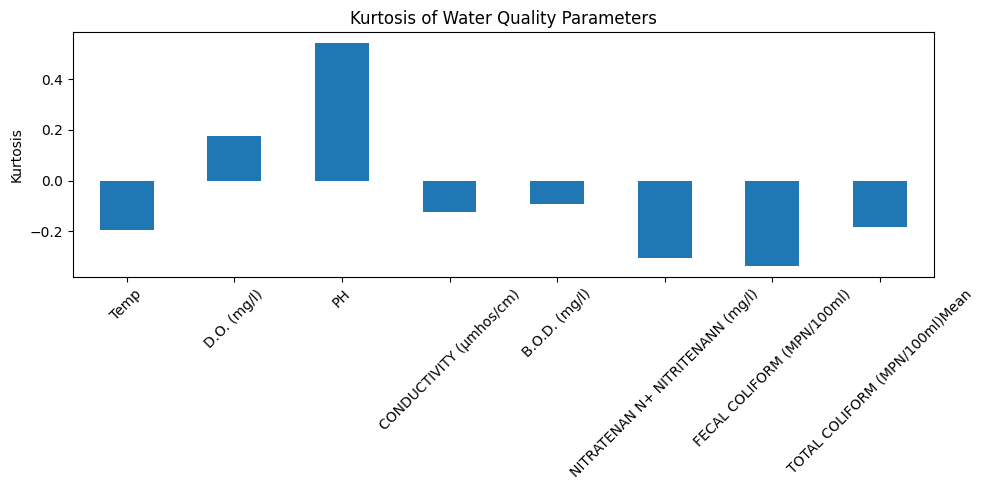

In [ ]:
# Calculate kurtosis for numerical columns
kurtosis_values = df[numeric_cols].kurt()

# Plot kurtosis values
kurtosis_values.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Kurtosis of Water Quality Parameters')
plt.ylabel('Kurtosis')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Observation:

PH has the highest positive kurtosis (~0.54), indicating a slightly more peaked distribution with somewhat heavier tails than the other parameters.

All remaining parameters have kurtosis values close to zero (-0.34 to 0.17), suggesting approximately normal distributions without significant extreme peaks after outlier treatment.

# **Skewness**

<Axes: xlabel='B.O.D. (mg/l)', ylabel='Count'>

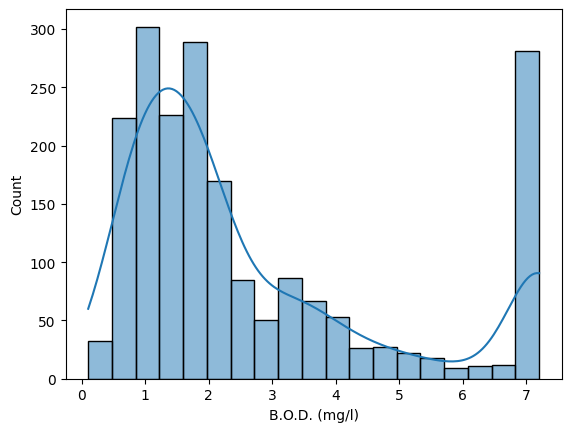

In [ ]:
# skewness

df[numeric_cols].skew()

# Visualize the distribution of B.O.D. values and assess data skewness using a histogram with KDE.
sns.histplot(df['B.O.D. (mg/l)'], kde=True)

**Observation:**

B.O.D. values are moderately right-skewed, with most observations concentrated between 1 and 3 mg/l.

No extreme outliers are visible, indicating that the IQR-based capping effectively reduced the influence of unusually high values.

# 3. Exploratory Data Analysis (EDA)

1.State-wise Sample Count (Count Plot)

2.Average DO by State (Bar Chart)

3.Year-wise Water Quality Trend (Line Plot)

4.BOD Distribution (Histogram)

5.Correlation Heatmap

6.Top 10 Most Polluted States by BOD

7.Fecal Coliform Distribution (Box Plot)

8.pH Distribution Across States (Violin Plot)

# **A. Univariate Analysis**

Analysis of individual variables to understand their distribution, variability, and data quality characteristics.

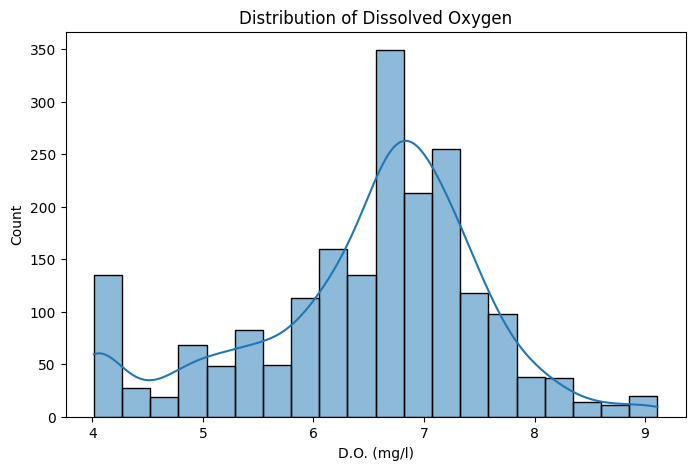

In [ ]:
#A. Univariate Analysis
##Distribution of Dissolved Oxygen
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['D.O. (mg/l)'], bins=20, kde=True)
plt.title('Distribution of Dissolved Oxygen')
plt.show()


**Insight:**

Dissolved Oxygen values are primarily concentrated between 6 and 8 mg/l, exhibiting a near-normal distribution with slight negative skewness and no significant outliers after treatment.

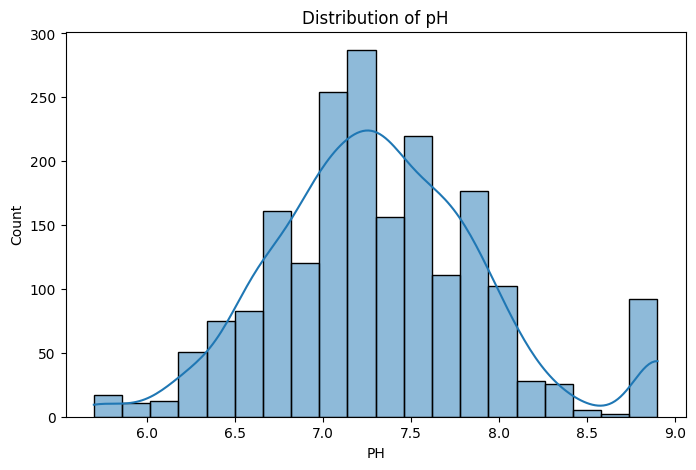

In [ ]:
#Distribution of pH
plt.figure(figsize=(8,5))
sns.histplot(df['PH'], bins=20, kde=True)
plt.title('Distribution of pH')
plt.show()

**Observation**

The pH values are concentrated around neutral levels (7.0–7.5), exhibiting an approximately normal distribution with slight positive skewness and no significant outliers.

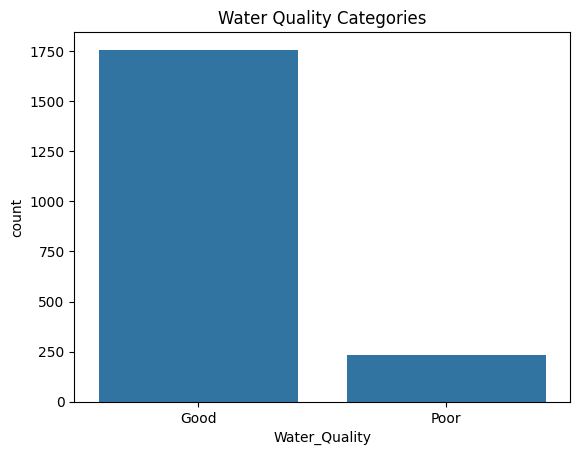

In [ ]:
#Water Quality Category Count
sns.countplot(data=df, x='Water_Quality')
plt.title('Water Quality Categories')
plt.show()

# **B. Bivariate Analysis**

Analysis of relationships between two variables to identify correlations and trends.

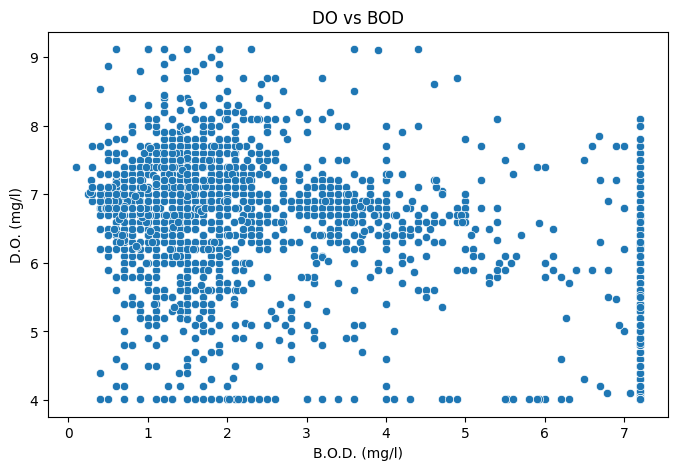

In [ ]:
#Do vs BD
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x='B.O.D. (mg/l)',
    y='D.O. (mg/l)'
)

plt.title('DO vs BOD')
plt.show()

**Insight:**

Higher BOD often leads to lower DO.

Indicates water pollution.

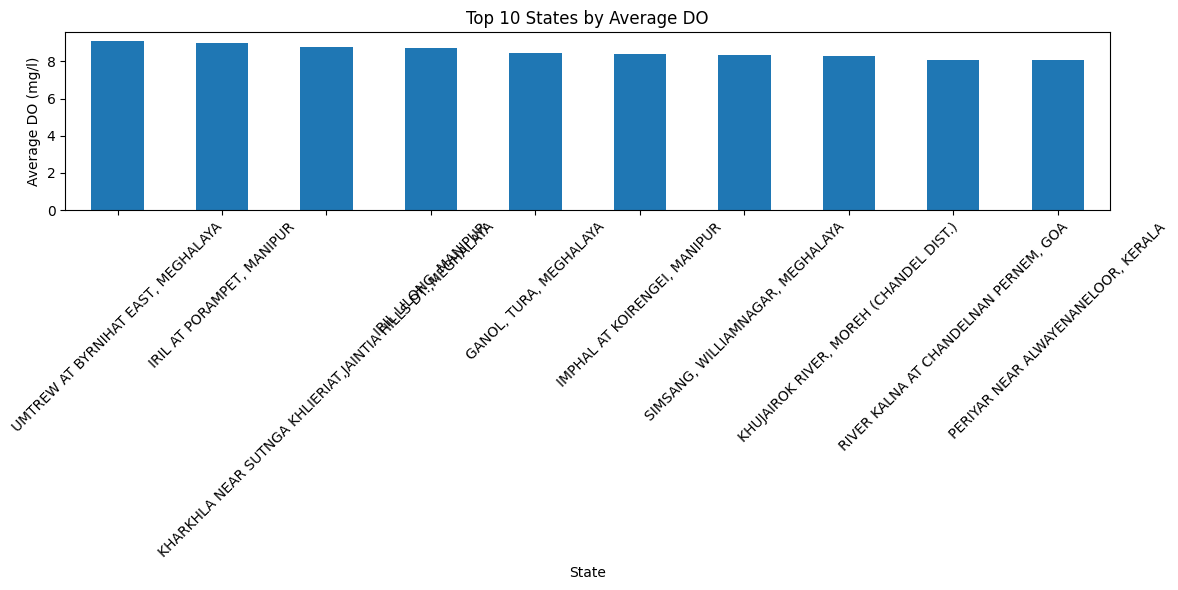

In [ ]:
import matplotlib.pyplot as plt

# Average DO by State
state_do = df.groupby('STATE')['D.O. (mg/l)'].mean()

# Top 10 states by average DO
top10_do = state_do.sort_values(ascending=False).head(10)

top10_do.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Top 10 States by Average DO')
plt.xlabel('State')
plt.ylabel('Average DO (mg/l)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

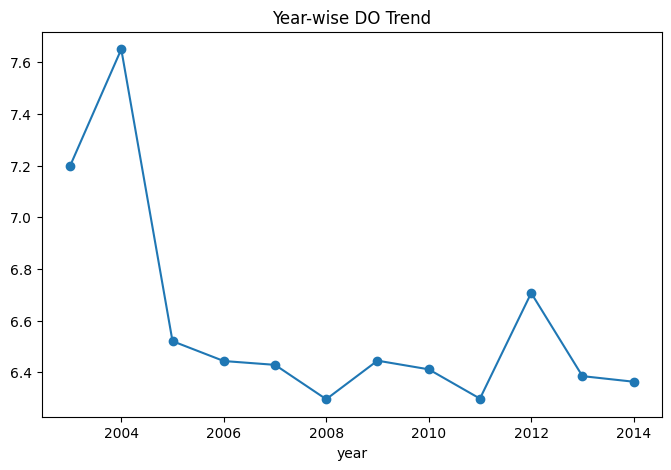

In [ ]:
# Year vs Average DO
year_do = df.groupby('year')['D.O. (mg/l)'].mean()

year_do.plot(
    marker='o',
    figsize=(8,5)
)

plt.title('Year-wise DO Trend')
plt.show()

**Insight 1:** Dissolved Oxygen (DO) levels peaked in 2004 (~7.65 mg/L) and then declined sharply in 2005, indicating a possible deterioration in overall water quality during that period.

**Insight 2:** From 2005 to 2014, DO levels remained relatively stable between 6.3–6.7 mg/L, suggesting consistent water quality conditions with only minor year-to-year fluctuations.

# **C. Multi Verse Analysis**

Analyzing the relationship among three or more variables simultaneously to understand patterns, interactions, and dependencies in the dataset.

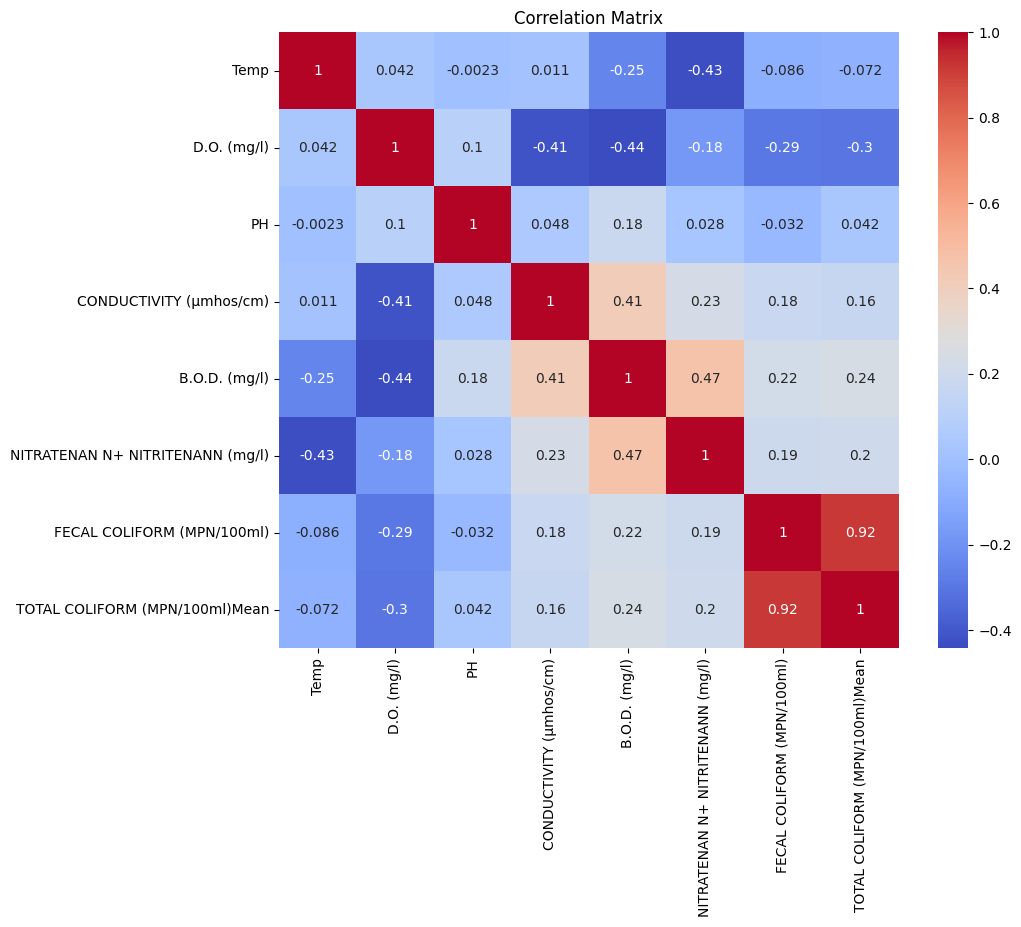

In [ ]:
# Correlation Heatmap
numeric_cols = [
    'Temp',
    'D.O. (mg/l)',
    'PH',
    'CONDUCTIVITY (µmhos/cm)',
    'B.O.D. (mg/l)',
    'NITRATENAN N+ NITRITENANN (mg/l)',
    'FECAL COLIFORM (MPN/100ml)',
    'TOTAL COLIFORM (MPN/100ml)Mean'
]

plt.figure(figsize=(10,8))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')
plt.show()

**Insight 1:** A very strong positive correlation (0.92) exists between Fecal Coliform and Total Coliform, indicating that locations with high fecal contamination also tend to have high overall bacterial contamination.

**Insight 2:** Dissolved Oxygen (DO) shows a moderate negative correlation with BOD (-0.44) and Conductivity (-0.41), suggesting that increased organic pollution and dissolved substances are associated with lower oxygen levels in water bodies.

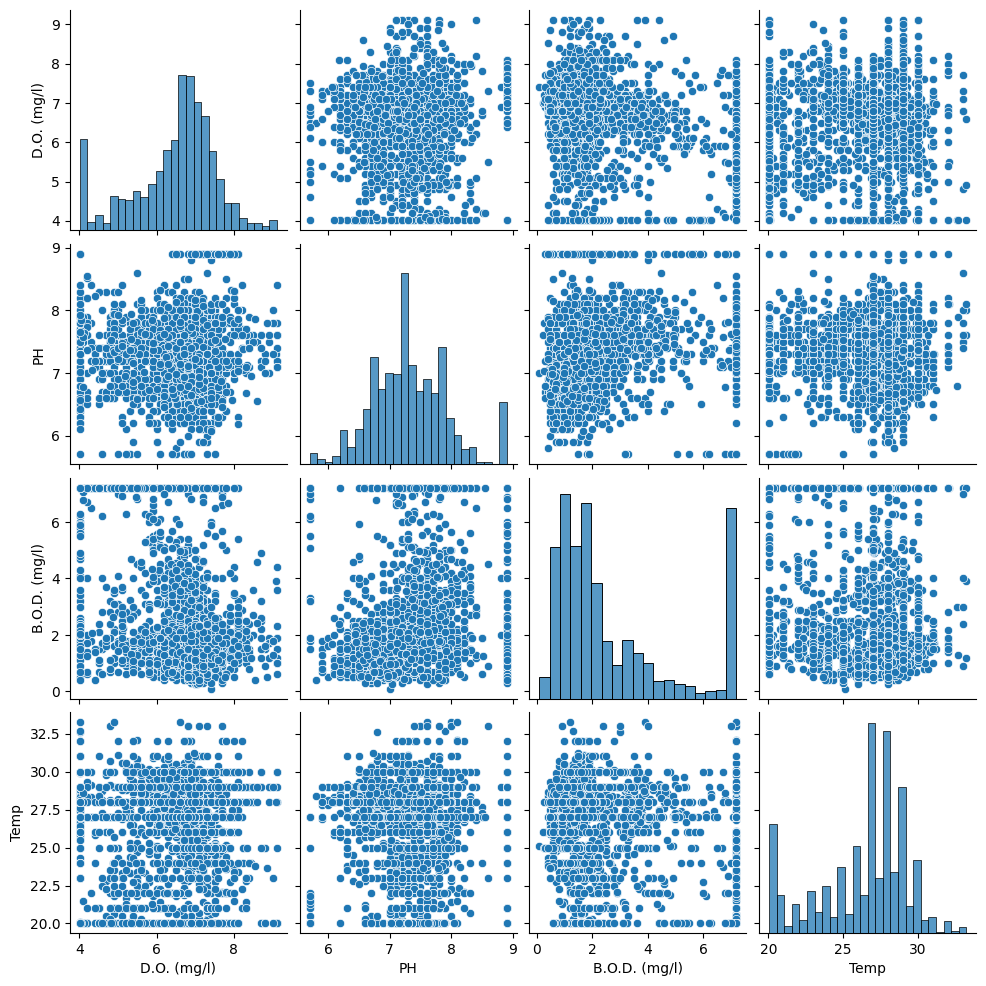

In [ ]:
# Pair Plot
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(
    df[['D.O. (mg/l)', 'PH', 'B.O.D. (mg/l)', 'Temp']],
    diag_kind='hist'
)

plt.show()

In [ ]:
# GroupBy Analysis
# Top 10 States by Average BOD

top_polluted = (
    df.groupby('STATE')['B.O.D. (mg/l)']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print(top_polluted)

STATE
BALEHWAR KHADI AT N.H. NO. 8                               7.2
AMLAKHADI AFTER CONFL. OF W. WATER FROM ANKLESH,GUJARAT    7.2
GHAGGAR AT KALA AMB D/S MARKANDA RIVER                     7.2
GHAGGAR AT D/S JHARMAL NADI, PUNJAB                        7.2
DAMANGANGA AT VILLAGE NAMDHA, VAPI                         7.2
DAMANGANGA AT ZARI CAUSE WAY BRIDGE,DAMAN                  7.2
DAMANGANGA DISCHARGE POINT OF DISTILLERY, DAMAN            7.2
D/S DHAKANSU NALLAH, PUNJAB                                7.2
DAMANGANGA AT DAMAN JETTY, MOTI DAMAN                      7.2
DAMANGANGA AT KACHIGAON D\S (DAMAN),GUJARAT                7.2
Name: B.O.D. (mg/l), dtype: float64


In [ ]:
# Top 10 States by Average DO
top_do = (
    df.groupby('STATE')['D.O. (mg/l)']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print(top_do)

STATE
UMTREW AT BYRNIHAT EAST, MEGHALAYA                            9.1125
IRIL AT PORAMPET, MANIPUR                                     9.0000
KHARKHLA NEAR SUTNGA KHLIERIAT,JAINTIA HILLS DT.,MEGHALAYA    8.8000
IRIL LILONG, MANIPUR                                          8.7000
GANOL, TURA, MEGHALAYA                                        8.4500
IMPHAL AT KOIRENGEI, MANIPUR                                  8.4000
SIMSANG, WILLIAMNAGAR, MEGHALAYA                              8.3500
KHUJAIROK RIVER, MOREH (CHANDEL DIST.)                        8.3000
RIVER KALNA AT CHANDELNAN PERNEM, GOA                         8.1000
PERIYAR NEAR ALWAYENANELOOR, KERALA                           8.1000
Name: D.O. (mg/l), dtype: float64


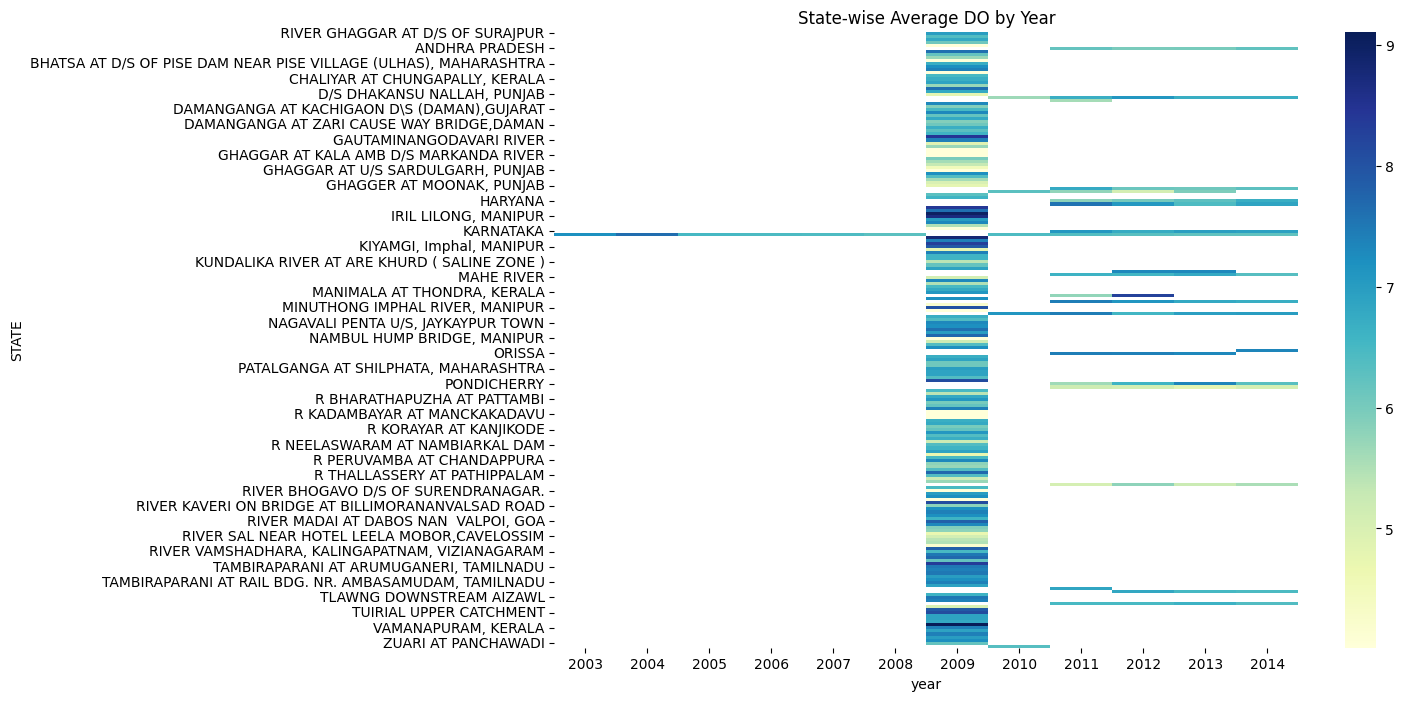

In [ ]:
# Heatmap of Pivot Table
# Create the pivot table for 'State-wise Average DO by Year'
pivot_table = df.pivot_table(index='STATE', columns='year', values='D.O. (mg/l)', aggfunc='mean')

plt.figure(figsize=(12,8))

sns.heatmap(
    pivot_table,
    cmap='YlGnBu'
)

plt.title('State-wise Average DO by Year')
plt.show()

# **Analysis of State wise Surface wate quality**

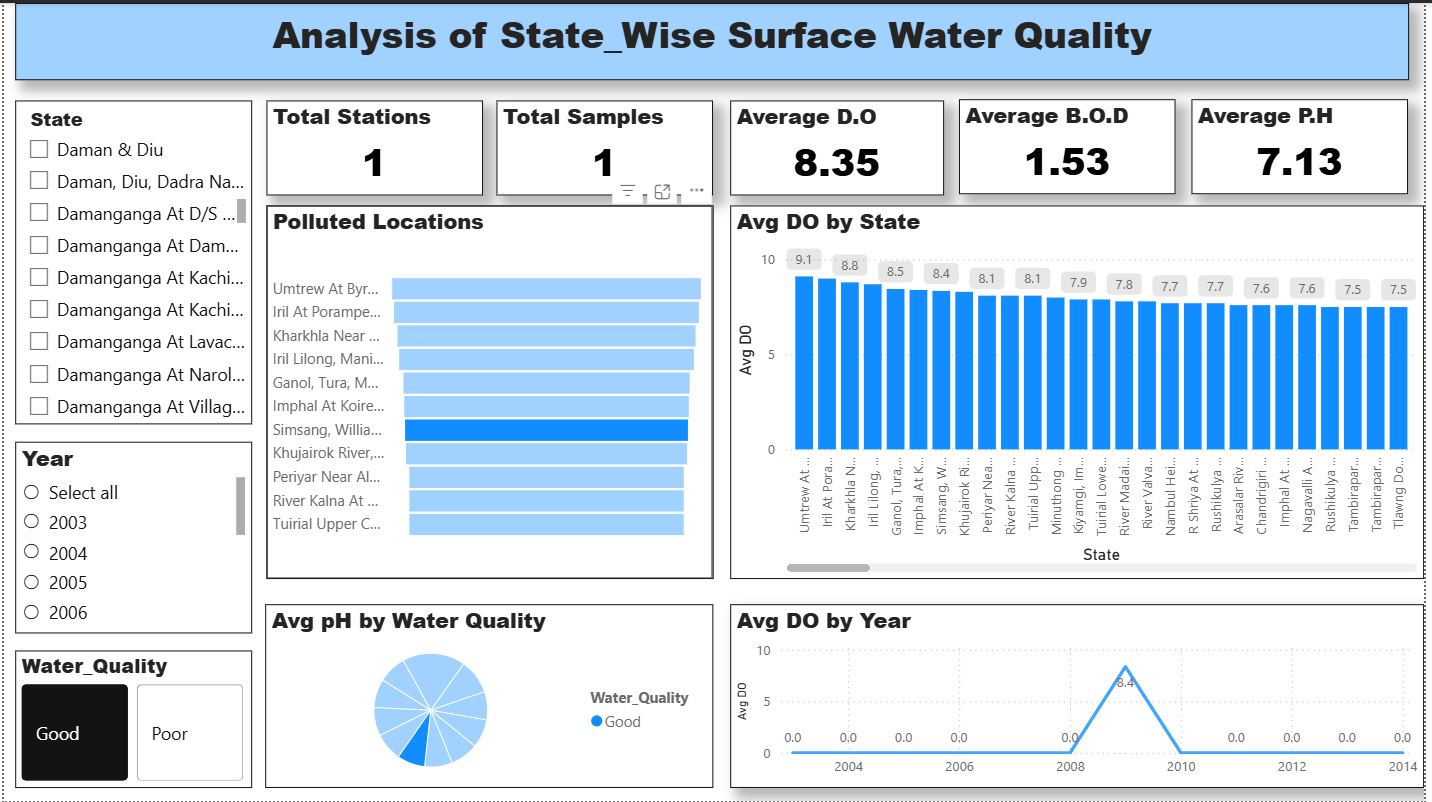

## Descriptive Analysis

### Insights

Based on the statistical summaries and kurtosis/skewness analysis performed earlier:

*   **Central Tendency & Spread**: The  output provides mean, median, standard deviation, min, and max values for all numeric columns, offering a fundamental understanding of each parameter's distribution.
*   **Kurtosis**: pH shows a slightly more peaked distribution with heavier tails (kurtosis ~0.54). Other parameters generally have kurtosis values close to zero, suggesting distributions close to normal after outlier treatment.
*   **Skewness**: The  distribution is moderately right-skewed, indicating a concentration of lower BOD values and a tail extending towards higher values. Dissolved Oxygen  exhibits a slight negative skew, suggesting values are mostly on the higher end of its range.

## Diagnostic Analysis

### Top 10 Most Polluted States by BOD (Chart)

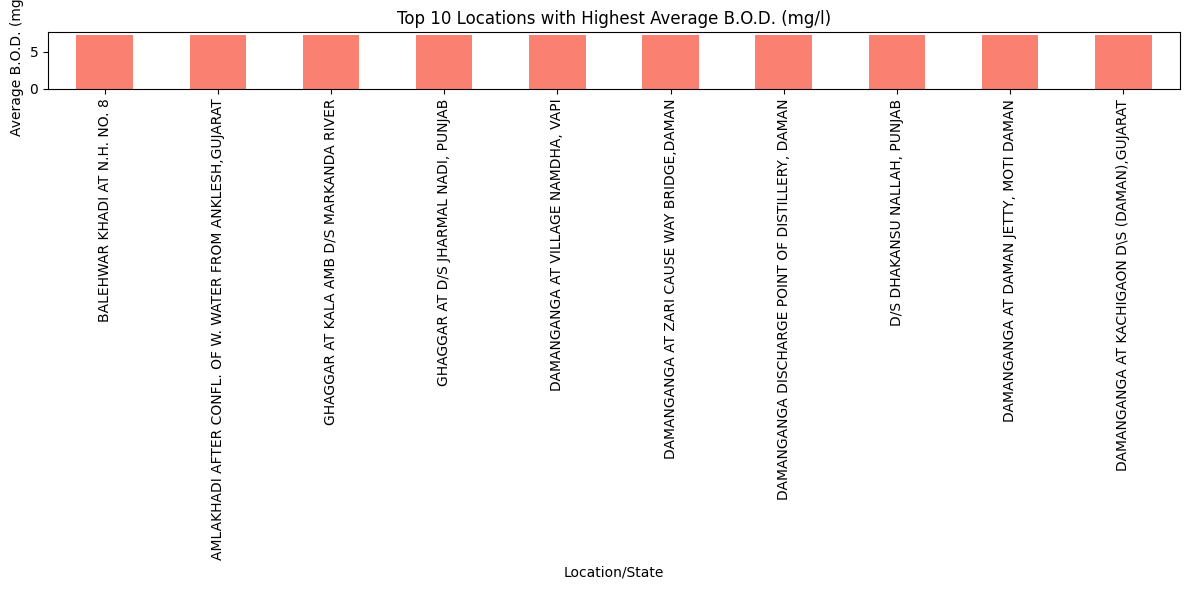

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the Top 10 Most Polluted States by BOD
plt.figure(figsize=(12, 6))
top_polluted.plot(kind='bar', color='salmon')
plt.title('Top 10 Locations with Highest Average B.O.D. (mg/l)')
plt.xlabel('Location/State')
plt.ylabel('Average B.O.D. (mg/l)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Insights
*   **High BOD Levels**: The plot clearly shows that locations such as 'BALEHWAR KHADI AT N.H. NO. 8', 'AMLAKHADI AFTER CONFL. OF W. WATER FROM ANKLESH,GUJARAT', and several sites exhibit the highest average BOD levels, indicating significant organic pollution.
*   **Concentration of Pollution**: Multiple entries for 'DAMANGANGA' and 'GHAGGAR' suggest localized pollution issues within those river systems or monitoring regions.

### Interpretation of your above chart
*   **Explain the Chart**: This bar chart visualizes the top 10 locations/states with the highest average Biological Oxygen Demand (BOD) values across the dataset.
*   **What is it saying?**: It highlights specific geographic areas or monitoring stations that consistently show elevated levels of organic pollution, as indicated by their high BOD concentrations. A higher BOD generally means more organic matter is present, which consumes dissolved oxygen and can harm aquatic life.
*   **What features you used?**: The chart uses the STATE (or LOCATIONS for more specific points within a state, as seen in the aggregated data) column on the x-axis and the B.O.D. (mg/l) column (specifically, the mean BOD) on the y-axis.
*   **From this what you are showing us?**: We are showing the geographical hotspots of water pollution based on BOD levels. This diagnostic insight can help identify areas requiring immediate attention for pollution control and environmental management.

## Predictive Analysis (using basic stats)

 ### Insights
*   **DO Decline after 2004**: The 'Year-wise DO Trend' plot  clearly shows a peak in Dissolved Oxygen (DO) levels around 2004, followed by a noticeable decline in 2005. This suggests a potential period of environmental stress or increased pollution during that time.
*   **Relative Stability**: After 2005, DO levels remained relatively stable, fluctuating within a narrower range, which might indicate a consistent level of water quality or the effectiveness of certain environmental regulations in maintaining DO levels.

### Interpretation of the 'Year-wise DO Trend' chart
*   **Explain the Chart**: The 'Year-wise DO Trend' chart is a line plot displaying the average Dissolved Oxygen (DO) levels across all monitoring stations for each year from 2003 to 2014.
*   **What is it saying?**: The chart indicates how the overall average water quality, specifically regarding oxygen availability for aquatic life, has changed over time. The decline after 2004 suggests a potential decrease in water health, while the subsequent stability indicates a plateau in this trend.
*   **What features you used?**: The x-axis represents the year and the y-axis represents the average D.O. (mg/l).
*   **From this what you are showing us?**: This analysis provides a basic temporal prediction or trend observation. It helps us understand the historical trajectory of water quality and anticipate future states if current conditions persist. For instance, without intervention, the stable but lower DO levels post-2005 might continue, suggesting a long-term impact on aquatic ecosystems.

## Prescriptive Analysis

### Recommendations
Based on the descriptive and diagnostic analysis, here are some prescriptive actions:

1.  **Targeted Intervention in High BOD Areas**: Focus pollution control efforts on the identified 'Top 10 Locations with Highest Average B.O.D. (mg/l)'. This includes investigating sources of organic pollution (industrial discharge, agricultural runoff, untreated sewage) and implementing specific remediation strategies.
2.  **Regular Monitoring of DO Levels**: Given the historical decline in DO after 2004, continuous and robust monitoring of Dissolved Oxygen is crucial, especially in vulnerable areas, to detect further deterioration and trigger timely interventions.
3.  **Wastewater Treatment Infrastructure**: In regions with consistently high BOD and coliform counts, investment in and upgrade of wastewater treatment plants are essential to reduce organic load and bacterial contamination in water bodies.
4.  **Promote Sustainable Practices**: Encourage sustainable agricultural practices, proper waste disposal, and industrial effluent treatment to prevent further degradation of water quality.
5.  **Public Awareness Campaigns**: Educate local communities about the importance of water quality and their role in preventing pollution, particularly regarding fecal contamination and waste disposal.

## Overall Analysis Summary


*   **Data Quality**: After cleaning, numerical columns were correctly typed, and missing values were imputed. Outliers were capped to ensure robust analysis.
*   **Parameter Distribution**: Dissolved Oxygen (DO) generally showed a healthy range (6-8 mg/L) with a near-normal distribution. pH values were concentrated around neutral (7.0-7.5). Biological Oxygen Demand (BOD) exhibited a moderate right-skew, indicating occasional higher pollution events.
*   **Statistical Overview**: Key water quality parameters like DO, pH, Conductivity, and BOD were statistically summarized, providing a foundational understanding of their central tendencies and dispersion.


*   **Pollution Hotspots**: The 'Top 10 Locations with Highest Average B.O.D. (mg/l)' chart clearly identified specific areas (e.g., DAMANGANGA sites, BALEHWAR KHADI) as significant organic pollution hotspots, requiring targeted environmental interventions.
*   **Correlation**: A strong positive correlation between Fecal Coliform and Total Coliform was observed, highlighting areas with severe bacterial contamination. A moderate negative correlation between DO and BOD/Conductivity reaffirmed that increased pollution leads to lower oxygen levels.


*   **DO Trend**: The 'Year-wise DO Trend' revealed a notable decline in average Dissolved Oxygen levels after 2004, suggesting a period of environmental stress. Post-2005, DO levels remained relatively stable but at a lower average, indicating a persistent water quality state.

*   **Targeted Interventions**: Recommendations include focusing pollution control efforts on identified high-BOD areas, implementing stricter wastewater treatment, and promoting sustainable practices.
*   **Continuous Monitoring**: Emphasizing regular monitoring of DO and other parameters is crucial for early detection of deterioration and timely response.
*   **Public Awareness**: Campaigns to educate communities on pollution prevention are vital for long-term water quality management.

### State-wise Sample Count Analysis

*   **Sampling Disparity**: An analysis of sample counts per state revealed a highly uneven distribution of monitoring efforts. Kerala, for instance, had a significantly higher number of samples compared to most other states, which had very few.
*   **Implication**: This disparity suggests that drawing comprehensive state-level comparisons or broad regional conclusions from this dataset should be done with caution, especially for states with limited data, as the available samples may not be representative of their overall water quality.

### Conclusion of State-wise Sample Count Analysis

  This analysis highlights the significant variability in water quality monitoring efforts across different states. While some states benefit from extensive sampling, others have very limited data, making direct comparisons and comprehensive regional assessments challenging. For future studies, a more uniform and consistent sampling strategy across all states would greatly enhance the reliability and representativeness of water quality analyses.